Found 10000 images belonging to 10 classes.
Found 500 images belonging to 10 classes.


/Users/arghaauddy/Desktop/Tomato Plant Leaf Disease Detection /venv/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 1430s 5s/step - accuracy: 0.2215 - loss: 2.1923 - val_accuracy: 0.5720 - val_loss: 1.3709
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 1384s 4s/step - accuracy: 0.6485 - loss: 1.3156 - val_accuracy: 0.7140 - val_loss: 0.8512
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 11258s 36s/step - accuracy: 0.7651 - loss: 0.8363 - val_accuracy: 0.7780 - val_loss: 0.6341
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 3372s 11s/step - accuracy: 0.8047 - loss: 0.6326 - val_accuracy: 0.8320 - val_loss: 0.5149
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 7051s 23s/step - accuracy: 0.8404 - loss: 0.5111 - val_accuracy: 0.8660 - val_loss: 0.4263
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 1856s 6s/step - accuracy: 0.8611 - loss: 0.4333 - val_accuracy: 0.8760 - val_loss: 0.3715
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 2068s 7s/step - accuracy: 0.8822 - loss: 0.3714 - val_accuracy: 0.8960 - val_loss: 0.3306
Epoch 8/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 1376s 4s/step - accuracy: 0.9028 - loss: 0.312

✅ Fine-tuned model saved at ../model/tomato_disease_detector_finetuned.h5


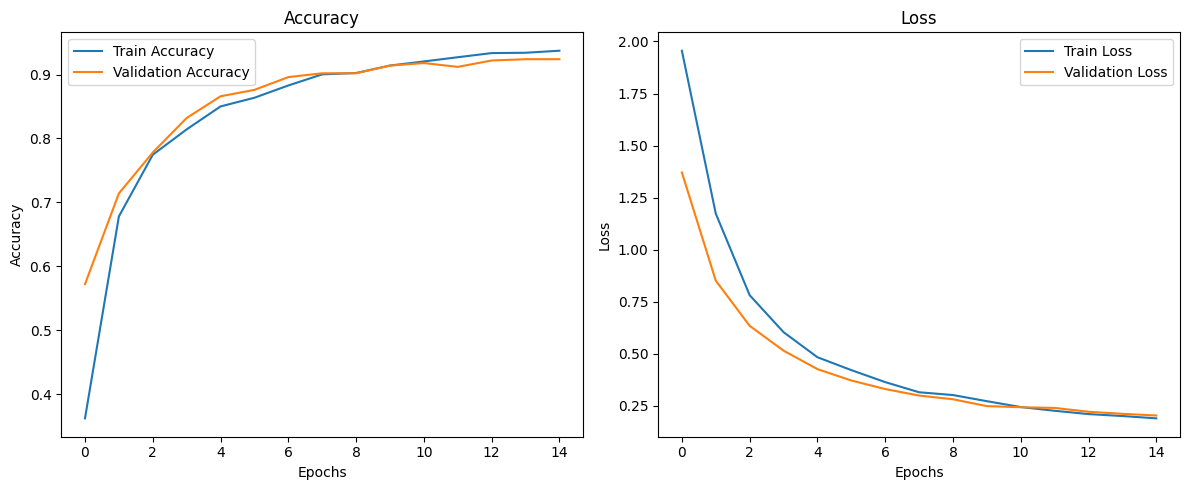

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet152V2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import SGD

# ------------------------------
# Paths
# ------------------------------
train_path = '../data/train'
val_path = '../data/new_val'
model_save_path = '../model/tomato_disease_detector_finetuned.h5'
img_size = (256, 256)
batch_size = 32
epochs = 15

# ------------------------------
# Data Augmentation
# ------------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

# ------------------------------
# Model Building
# ------------------------------
base_model = ResNet152V2(
    weights='imagenet',
    include_top=False,
    input_shape=(256, 256, 3)
)

# Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
predictions = Dense(train_generator.num_classes, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=predictions)

# ------------------------------
# Fine-Tuning Setup
# ------------------------------

# 1. Freeze all layers initially
for layer in base_model.layers:
    layer.trainable = False

# 2. Unfreeze the last N layers for fine-tuning
fine_tune_at = 50  # Unfreeze last 50 layers
for layer in base_model.layers[-fine_tune_at:]:
    layer.trainable = True

# 3. Compile with a low learning rate
model.compile(
    optimizer=SGD(learning_rate=1e-4, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ------------------------------
# Train Model
# ------------------------------
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs
)

# Save model
os.makedirs('../model', exist_ok=True)
model.save(model_save_path)
print(f"✅ Fine-tuned model saved at {model_save_path}")

# ------------------------------
# Plot Training & Validation Metrics
# ------------------------------
plt.figure(figsize=(12,5))

# Accuracy Plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
os.makedirs("results", exist_ok=True)
plt.savefig("results/training_validation_metrics.png", dpi=300)
plt.show()
